In [1]:
# %%capture cap
!pip install -q ipywidgets
!pip install -q autogluon scikit-learn==1.5.2 
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.9/454.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.3/487.3 kB 17.6 MB/s eta 0:00:

In [2]:
import torch
import os
import pydot

import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from time import time, sleep
from itertools import combinations

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option('display.max_columns', 100)
# plt.style.use("ggplot")
# sns.set_style("whitegrid")

## -- Ansi color codes --
COLOR = '\033[32m'
RESET = '\033[0m'

print("Packages import succesful!")

Packages import succesful!


In [3]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
tn = pd.read_csv(PATH+"train.csv").drop('id', axis=1)

TARGET = tn.columns[-1]
TARGET

'exam_score'

In [4]:
## -- Append predicted columns as extra features --
## -- os.walk: Deep search with subfolders --
def dataloader(filepath, train_prefix, test_prefix):    
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()
    
    print('Loading .npy files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f'{i}%.. ', end='')
            if file.endswith('.npy') and train_prefix in file:
                train_path = np.load(os.path.join(root, file))
                train_df = pd.concat([train_df, pd.Series(train_path, name=file[4:-4])], axis=1)
            elif file.endswith('.npy') and test_prefix in file:
                test_path = np.load(os.path.join(root, file))
                test_df = pd.concat([test_df, pd.Series(test_path, name=file[5:-4])], axis=1)
    print()

    print('Loading .parquet files: ', end='')
    for (root, dirs, files) in os.walk(filepath):
        for i, file in enumerate(sorted(files), 1):
            if i%5 == 0: print(f"{i}%.. ", end="")
            if file.endswith('.parquet') and train_prefix in file:
                train_path = os.path.join(root, file)
                train_df = pd.concat([train_df, pd.read_parquet(train_path)], axis=1)
            elif file.endswith('.parquet') and test_prefix in file:
                test_path = os.path.join(root, file)
                test_df = pd.concat([test_df, pd.read_parquet(test_path)], axis=1)
    print()
    print(f"Total oof  models: {len(train_df.columns)} || Shape: {train_df.shape}")
    print(f"Total pred models: {len(test_df.columns)} || Shape: {test_df.shape}")
    print()

    return train_df, test_df

def rename_duplicate_cols(df: pd.DataFrame) -> pd.DataFrame:
    original_cols = list(df.columns)
    new_cols = []
    # Track how many times we've seen each original name
    seen = {}

    for col in tqdm(original_cols, desc="Fixing columns"):
        if col not in seen:
            # First occurrence: keep name unchanged
            seen[col] = 1
            new_cols.append(col)
        else:
            # Duplicate: append suffix _k where k starts at 0
            suffix = seen[col] - 1 # 0 for first duplicate, 1 for second,
            new_name = f"{col}_{suffix}"
            new_cols.append(new_name)
            seen[col] += 1

    # Apply new column names
    df_renamed = df.copy()
    df_renamed.columns = new_cols
    print(f"{COLOR}Columns fixed!!!{RESET}")

    return df_renamed


In [5]:
PATHS = [
    '/kaggle/input/',
]

## -- Load dataframes --
oofs = []
preds  = []

## -- Load train/test datasets --
for p in PATHS:
    tr, ts = dataloader(p, 'oof', 'test')
    oofs.append(tr)
    preds.append(ts)

## -- Concat datasets --
oof_df = pd.concat(oofs, axis=1)
pred_df  = pd.concat(preds, axis=1)

print('Data loaded', oof_df.shape, pred_df.shape)

# ## -- Drop models if necessary --
# for c in oof_df.columns:
#     if 'L2' in c or 'L3' in c: #
#         oof_df.drop([c], axis=1, inplace=True)
#         pred_df.drop([c], axis=1, inplace=True)
#     elif c == TARGET:
#         oof_df.drop([c], axis=1, inplace=True)
        
print('-'*50)

## -- Check for missingness --
print(f'Train Null values: {oof_df.isna().sum().sum()}')
print(f'Test  Null values: {pred_df.isna().sum().sum()}')

print('-'*50)

## -- Apply column rename function --
oof_df = rename_duplicate_cols(oof_df)
pred_df = rename_duplicate_cols(pred_df)

display(oof_df.head(3))
display(pred_df.head(3))

Loading .npy files: 5%.. 10%.. 15%.. 20%.. 5%.. 5%.. 5%.. 5%.. 10%.. 5%.. 10%.. 
Loading .parquet files: 5%.. 10%.. 15%.. 20%.. 5%.. 5%.. 5%.. 5%.. 10%.. 5%.. 10%.. 
Total oof  models: 63 || Shape: (630000, 63)
Total pred models: 63 || Shape: (270000, 63)

Data loaded (630000, 63) (270000, 63)
--------------------------------------------------
Train Null values: 0
Test  Null values: 0
--------------------------------------------------


Fixing columns:   0%|          | 0/63 [00:00<?, ?it/s]

Columns fixed!!!


Fixing columns:   0%|          | 0/63 [00:00<?, ?it/s]

Columns fixed!!!


,py_catb_62892,py_lgb_61185,py_mlpPLR_68655,py_mlpRTDL_66901,py_resRTDL_65146,py_tabM_60593,py_xgb_60595,bartz_base_66306,bartz_tabM_pseudo_65653,py_tabM3_meta+fe60124,py_tabM2_meta+fe60589,py_tabM_meta+fe6106,LGB_bag_540_8_61275,LGB_bag_540_8_cme_61794,LGB_goss_540_8_61089,LGB_goss_540_8_cme_61386,LGB_bag_480_-1_61043,LGB_bag_480_-1_cme_61908,LGB_goss_480_-1_60953,LGB_goss_480_-1_cme_61656,LGB_bag_540_-1_61059,LGB_bag_540_-1_cme_61349,LGB_goss_540_-1_60957,LGB_goss_540_-1_cme_6124,lgb_goss_ext_005_61092,XGB_gbdt_60118,XGB_loss_60249,XGB_grad_60263,XGBxtend_gbdt_61003,XGBxtend_loss_61085,XGBxtend_gbdt_61003_0,XGBxtend_loss_61085_0,XGBgbdt_59989,XGBloss_60124,XGBgrad_60152,hist__69968,hist_cme__69758,hist_TE__6898,hist_cme_TE_69097,hist__6964,hist_cme__69907,hist_TE__69375,hist_cme_TE_68866,ridge_stack76781,sk_hc76798,xgb_basescore_602,xgb_basescore_60549,xgb_basescore_6067,xgb_gbdt_ext_60445,xgb_loss_ext_005_60676,xgb_AG_basescore5_60594,xgb_AG_basescore5_60817,xgb_over_lr,xgb_over_ridgeCV,xgb_over_mlp,xgb_over_lr_0,xgb_over_ridgeCV_0,xgb_over_mlp_0,xgb_tabM0_pseudo_59841,xgb_tabM1_pseudo_59851,xgb_tabM2_pseudo_59842,xgb_tabM3_pseudo_59842,xgb_tabM_pseudo_60575
0,86.688492,86.140564,85.738118,85.902185,87.139495,86.612518,86.144653,86.130020,85.914291,85.920105,86.170883,85.917885,85.318904,85.387741,85.742981,84.997785,85.680118,85.773735,85.706107,85.654820,85.651155,86.001912,85.575590,85.819090,87.217672,85.782745,85.731857,85.992737,86.586670,86.881119,86.586670,86.881119,85.708923,85.808243,85.915421,85.353533,85.687152,85.409210,85.374487,84.384845,85.141444,85.290123,85.784180,85.034216,85.093428,86.154221,85.515030,85.649948,86.771828,87.210014,86.513184,86.922592,87.516899,88.327248,86.565460,87.287926,87.025757,86.068924,86.187370,86.370224,86.219353,87.097427,86.268631
1,62.633961,61.034485,62.166407,61.022569,60.568737,61.261623,61.474064,62.045822,61.573631,60.960331,61.302273,61.855743,61.292052,62.674258,61.815940,62.707770,61.340938,61.198899,60.826019,61.027153,60.666148,62.591098,61.052287,62.498479,62.491562,60.526791,61.457813,61.206097,61.844688,62.011227,61.844688,62.011227,61.312813,61.000328,61.397327,64.307580,64.505596,62.963127,63.299097,63.259405,63.964815,63.577783,63.558337,63.930631,63.771228,61.211216,61.538975,61.225441,62.271206,62.502407,61.238247,61.462227,62.838547,63.109093,62.679665,63.699028,64.167763,63.423134,61.267548,61.711746,61.394009,61.783325,61.147091
2,75.477058,74.895561,74.309942,73.567834,72.474952,73.059113,75.284302,74.179680,73.660393,73.960136,73.615585,74.100609,74.226975,74.905604,74.767358,74.023411,74.464471,74.504888,74.688106,74.405696,74.360232,74.059751,74.425620,74.131461,74.530084,74.903198,74.977432,74.916412,73.799271,73.861023,73.799271,73.861023,74.598541,74.384422,74.637077,75.526277,75.458655,75.434530,75.263758,75.578656,75.774778,74.165394,75.287001,75.928967,75.931758,73.914948,74.107468,74.164413,74.198845,73.925819,75.255173,75.465096,74.393341,74.723068,75.265228,74.261093,74.252678,72.927773,74.603096,74.824989,74.866760,74.990540,73.924393


,py_catb_62892,py_lgb_61185,py_mlpPLR_68655,py_mlpRTDL_66901,py_resRTDL_65146,py_tabM_60593,py_xgb_60595,bartz_base_66306,bartz_tabM_pseudo_65653,py_tabM3_meta+fe60124,py_tabM2_meta+fe60589,py_tabM_meta+fe6106,LGB_bag_540_8_61275,LGB_bag_540_8_cme_61794,LGB_goss_540_8_61089,LGB_goss_540_8_cme_61386,LGB_bag_480_-1_61043,LGB_bag_480_-1_cme_61908,LGB_goss_480_-1_60953,LGB_goss_480_-1_cme_61656,LGB_bag_540_-1_61059,LGB_bag_540_-1_cme_61349,LGB_goss_540_-1_60957,LGB_goss_540_-1_cme_6124,lgb_goss_ext_005_61092,XGB_gbdt_60118,XGB_loss_60249,XGB_grad_60263,XGBxtend_gbdt_61003,XGBxtend_loss_61085,XGBxtend_gbdt_61003_0,XGBxtend_loss_61085_0,XGBgbdt_59989,XGBloss_60124,XGBgrad_60152,hist__69968,hist_cme__69758,hist_TE__6898,hist_cme_TE_69097,hist__6964,hist_cme__69907,hist_TE__69375,hist_cme_TE_68866,ridge_stack76781,sk_hc76798,xgb_basescore_602,xgb_basescore_60549,xgb_basescore_6067,xgb_gbdt_ext_60445,xgb_loss_ext_005_60676,xgb_AG_basescore5_60594,xgb_AG_basescore5_60817,xgb_over_lr,xgb_over_ridgeCV,xgb_over_mlp,xgb_over_lr_0,xgb_over_ridgeCV_0,xgb_over_mlp_0,xgb_tabM0_pseudo_59841,xgb_tabM1_pseudo_59851,xgb_tabM2_pseudo_59842,xgb_tabM3_pseudo_59842,xgb_tabM_pseudo_60575
0,69.937656,68.801832,69.578282,70.544626,69.844086,70.16837,68.356943,69.479706,69.557053,70.051081,69.986753,69.887014,69.085864,69.226077,68.976145,68.933155,68.902509,68.820401,68.904376,68.744666,68.983265,68.972823,69.055517,69.149427,69.044581,68.806736,69.047075,68.926661,69.063478,69.184321,69.063478,69.184321,68.885216,69.175027,68.978607,70.473159,70.286991,70.855875,71.198036,70.351699,70.308357,70.860897,71.218049,71.906423,71.864230,68.628630,68.717550,68.984600,68.819203,69.015012,68.579308,68.672778,70.513012,70.597206,70.711028,70.189158,70.170502,69.670619,68.906935,68.510226,68.871183,68.382638,68.742071
1,69.269369,68.820347,66.634049,67.672073,66.006580,66.92374,68.975389,67.693649,68.646309,65.911273,66.586623,66.182148,68.505683,68.520475,68.597972,68.482443,68.695055,68.630278,68.768327,68.435194,68.608486,68.886083,68.795293,68.694330,68.317784,68.434294,68.426260,68.380260,67.413956,67.474291,67.413956,67.474291,68.332038,68.307899,68.355513,69.394816,69.790828,68.684939,69.029887,69.881703,69.535291,68.489706,68.821750,70.525372,70.498294,68.538184,67.810481,68.528937,67.655030,67.731277,69.844801,69.293248,70.852183,70.855190,70.723640,69.450539,69.281650,68.584525,67.903807,68.547585,67.919798,68.441369,66.791371
2,88.729725,89.624125,90.277119,90.985393,90.548849,90.62045,90.009252,88.184113,89.441544,90.260964,90.660124,90.886374,90.124104,89.648565,89.940830,89.636872,90.276528,89.542762,90.288202,89.691004,90.297098,89.826149,90.210182,89.924384,89.742585,90.245839,90.303782,90.116723,90.451480,90.457949,90.451480,90.457949,90.171266,90.419130,90.066766,88.894744,88.711039,88.880809,88.855335,88.833979,88.819031,89.082933,88.829361,87.477449,87.554938,90.764555,90.494648,90.997976,90.457200,90.401023,90.243106,90.934801,87.900454,88.064122,88.024510,88.993005,89.002260,89.184582,91.265516,90.848653,91.282242,90.670236,90.634073


In [6]:
MODELS_PATH = "/kaggle/working/AG_TEST_SCORES_models/"
# !rm -r {MODELS_PATH}

In [7]:
from autogluon.tabular import TabularPredictor

In [8]:
## -- RUN 1: Use train data -- 
predictor = TabularPredictor(
                label = TARGET,
         # problem_type = "binary",
          # eval_metric = "roc_auc",
                 path = MODELS_PATH,
    ).fit(
                   train_data = pd.concat([oof_df, tn[TARGET]], axis=1),
                      presets = "best",
                # num_bag_folds = 5,
             dynamic_stacking = False,
             num_stack_levels = 1,
                   time_limit = 3600*10,
                   # auto_stack = False,
                 # num_bag_sets = 2,
                  # ag_args_fit = {'num_cpus': os.cpu_count()},
) 

Preset alias specified: 'best' maps to 'best_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat Jan 17 11:20:45 UTC 2026
CPU Count:          4
Memory Avail:       28.62 GB / 31.35 GB (91.3%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 36000s
AutoGluon will save models to "/kaggle/working/AG_TEST_SCORES_models"
Train Data Rows:    630000
Train Data Columns: 63
Label Column:       exam_score
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and label-values can't be converted to int).
	Label info (max, min, mean, stddev): (100.0, 19.599, 62.

In [9]:
## -- Get Summary -- 
print(f"-> Total models : {len(predictor.model_names())}")
print(f"-> Best model   : {predictor.model_best}\n") 

## -- RUN 1 RESULTS -- 
leaderboard = predictor.leaderboard(silent=True)
leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

-> Total models : 18
-> Best model   : WeightedEnsemble_L3



,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,-8.577737,root_mean_squared_error,539.682769,35657.470205,0.012133,1.862841,3,True,18
1,WeightedEnsemble_L2,-8.578074,root_mean_squared_error,300.270327,7826.585188,0.013513,1.818967,2,True,14
2,NeuralNetFastAI_BAG_L1,-8.579427,root_mean_squared_error,12.202037,1652.859026,12.202037,1652.859026,1,True,6
3,LightGBM_BAG_L2,-8.583148,root_mean_squared_error,399.062892,23821.500165,6.424209,171.589236,2,True,16
4,LightGBMXT_BAG_L2,-8.583718,root_mean_squared_error,498.096270,24275.670526,105.457587,625.759597,2,True,15
5,LightGBMXT_BAG_L1,-8.584237,root_mean_squared_error,122.163721,631.202422,122.163721,631.202422,1,True,1
6,LightGBM_BAG_L1,-8.584274,root_mean_squared_error,8.903920,190.723318,8.903920,190.723318,1,True,2
7,LightGBM_r131_BAG_L1,-8.584321,root_mean_squared_error,96.201774,524.811448,96.201774,524.811448,1,True,12
8,XGBoost_BAG_L1,-8.585643,root_mean_squared_error,8.191200,161.597178,8.191200,161.597178,1,True,7
9,LightGBMLarge_BAG_L1,-8.586861,root_mean_squared_error,15.683847,255.852844,15.683847,255.852844,1,True,9


In [10]:
# ## -- RUN 2: Use original data as extra learning input --
# predictor.fit_pseudolabel(
#                 orig,
#                 use_ensemble = True,
#                 fit_ensemble = True,
#                 time_limit   = 3600*5,
# )

In [11]:
# ## -- Get Summary -- 
# print(f"-> Total models : {len(predictor.model_names())}")
# print(f"-> Best model   : {predictor.model_best}\n") 

# ## -- RUN 2 RESULTS -- 
# leaderboard = predictor.leaderboard(silent=True)
# leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

In [12]:
## -- Create folder directory to save predictions --
SAVE_PATH = '/kaggle/working/AG_TEST_SCORES_test/'
FILE_NAME = 'ag_TEST_oof-test.parquet'
!mkdir {SAVE_PATH}

In [13]:
%%time
## -- Generate predictions for all models --
ag_multi_test = predictor.predict_multi(pred_df)

## -- Save TEST predictions of all models --
final_test_data = {}
DESC = "Exporting TEST predictions"

for k, v in tqdm(ag_multi_test.items(), desc=DESC):
    k_renamed = k.replace('_', '')
    final_test_data[k_renamed] = v

file_name = f"{SAVE_PATH}test_{FILE_NAME}"

final_test_df = pd.DataFrame(final_test_data)
final_test_df.to_parquet(file_name, index=False)
final_test_df.head()

Exporting TEST predictions:   0%|          | 0/18 [00:00<?, ?it/s]

CPU times: user 21min 47s, sys: 37.3 s, total: 22min 24s
Wall time: 11min 8s


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,CatBoostr9BAGL1,WeightedEnsembleL2,LightGBMXTBAGL2,LightGBMBAGL2,RandomForestMSEBAGL2,WeightedEnsembleL3
0,69.481873,69.439728,70.376091,69.358643,69.825142,69.278221,69.464745,69.263329,69.532471,69.504814,69.467041,69.512466,64.628662,69.373718,69.492050,69.434807,69.590324,69.374390
1,67.644714,68.074692,67.666443,67.901970,67.618195,67.202232,68.272179,67.458290,68.129684,67.796059,66.750252,68.158546,64.381485,67.329391,67.778824,68.004234,68.170860,67.400833
2,90.851181,90.981873,91.629639,90.696312,91.225754,90.522278,90.777359,91.300758,90.926727,90.789017,90.913765,90.989334,71.265015,90.697716,90.767227,90.534393,91.460365,90.746872
3,56.562157,56.723587,56.646618,56.601921,56.744431,56.712345,56.636604,56.870792,56.527866,56.657745,57.153381,56.576305,60.517746,56.759472,56.692272,56.816242,56.018745,56.707573
4,46.708565,46.918427,47.564041,46.495201,47.520844,46.544373,46.933590,47.087379,46.916046,46.617226,46.793236,46.886852,57.577209,46.683044,46.724228,46.770382,47.584991,46.735409


In [14]:
%%time
## -- Get OOF predictions of all models --
ag_multi_oof_preds = {}
DESC1 = "Processing OOF probabilities"

for model in tqdm(predictor.model_names(), desc=DESC1):
    ag_multi_oof_preds[model] = predictor.predict_oof(
                                             model = model,
                                        train_data = pd.concat([oof_df, tn[TARGET]], axis=1),
                                )

final_oof_data = {}
DESC2 = "Exporting OOF predictions"

for k, v in tqdm(ag_multi_oof_preds.items(), desc=DESC2):
    k_renamed = k.replace('_', '')
    final_oof_data[k_renamed] = v

file_name = f"{SAVE_PATH}oof_{FILE_NAME}"

final_oof_df = pd.DataFrame(final_oof_data)
final_oof_df.to_parquet(file_name, index=False)
final_oof_df.head()

Processing OOF probabilities:   0%|          | 0/18 [00:00<?, ?it/s]

Exporting OOF predictions:   0%|          | 0/18 [00:00<?, ?it/s]

CPU times: user 3.67 s, sys: 7.59 s, total: 11.3 s
Wall time: 14.1 s


,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,CatBoostr9BAGL1,WeightedEnsembleL2,LightGBMXTBAGL2,LightGBMBAGL2,RandomForestMSEBAGL2,WeightedEnsembleL3
0,86.257484,86.157631,86.482765,86.482239,86.003426,86.779968,86.215561,86.992729,86.387726,86.511559,87.626205,86.333305,69.901535,86.747231,86.448006,86.547775,86.429436,86.751343
1,61.471119,61.261997,59.705566,61.022644,61.183540,61.108730,61.357700,60.965569,61.128651,60.953304,61.292183,61.170525,62.135342,61.163296,61.194504,61.250397,61.086960,61.149498
2,74.225433,74.319946,73.258751,74.561546,73.951767,73.940483,74.350471,74.170761,74.184982,74.027687,73.767029,74.342003,66.268059,73.987000,74.133163,74.040955,73.369164,73.929359
3,48.292900,48.165867,48.706093,47.972542,47.623650,48.547947,48.175747,49.596386,48.219757,47.625736,49.068802,48.196949,57.975868,48.472755,48.405838,48.175110,48.066139,48.474689
4,96.801048,96.487457,96.305214,96.186394,96.603043,96.252289,96.246407,95.174812,96.313126,96.229034,97.722923,96.485390,72.970894,96.524628,96.969490,96.300980,96.553810,96.543854


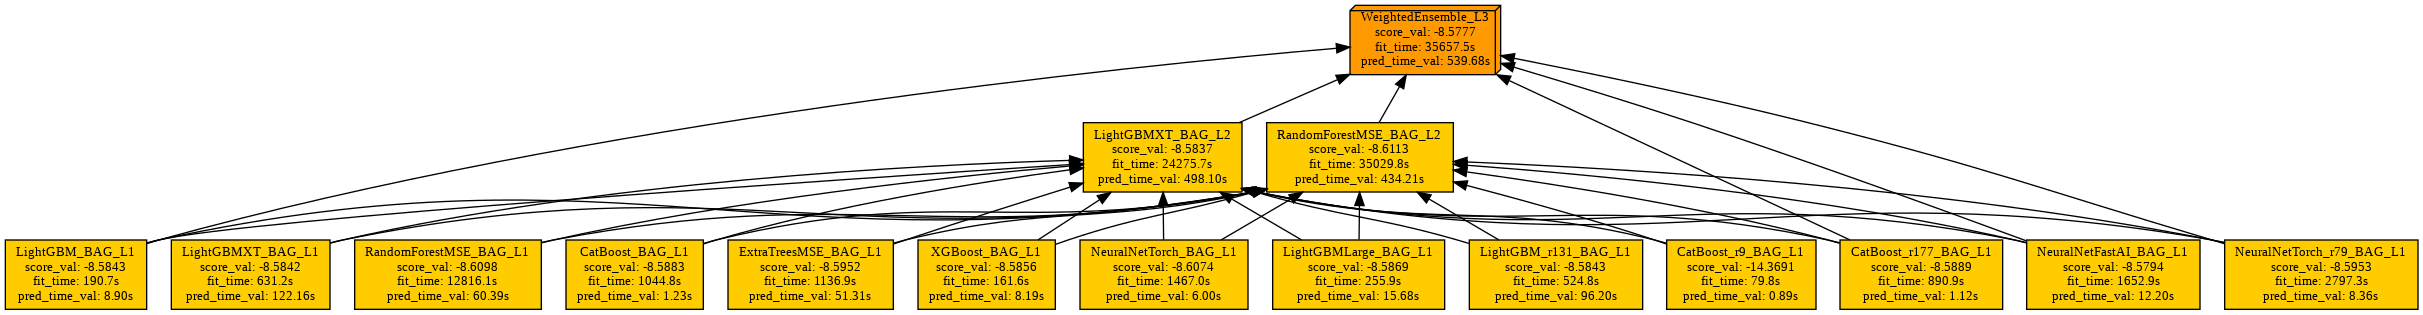

In [15]:
predictor.plot_ensemble_model(filename='ensemble_model.png')
display(Image(f'{MODELS_PATH}ensemble_model.png'))

In [16]:
# !zip -r /kaggle/working/AG_accident_models /kaggle/working/AG_accident_models.zip
# !zip -r {FOLDER}{NAME_EXT}.zip /kaggle/working/{FOLDER}{NAME_EXT}

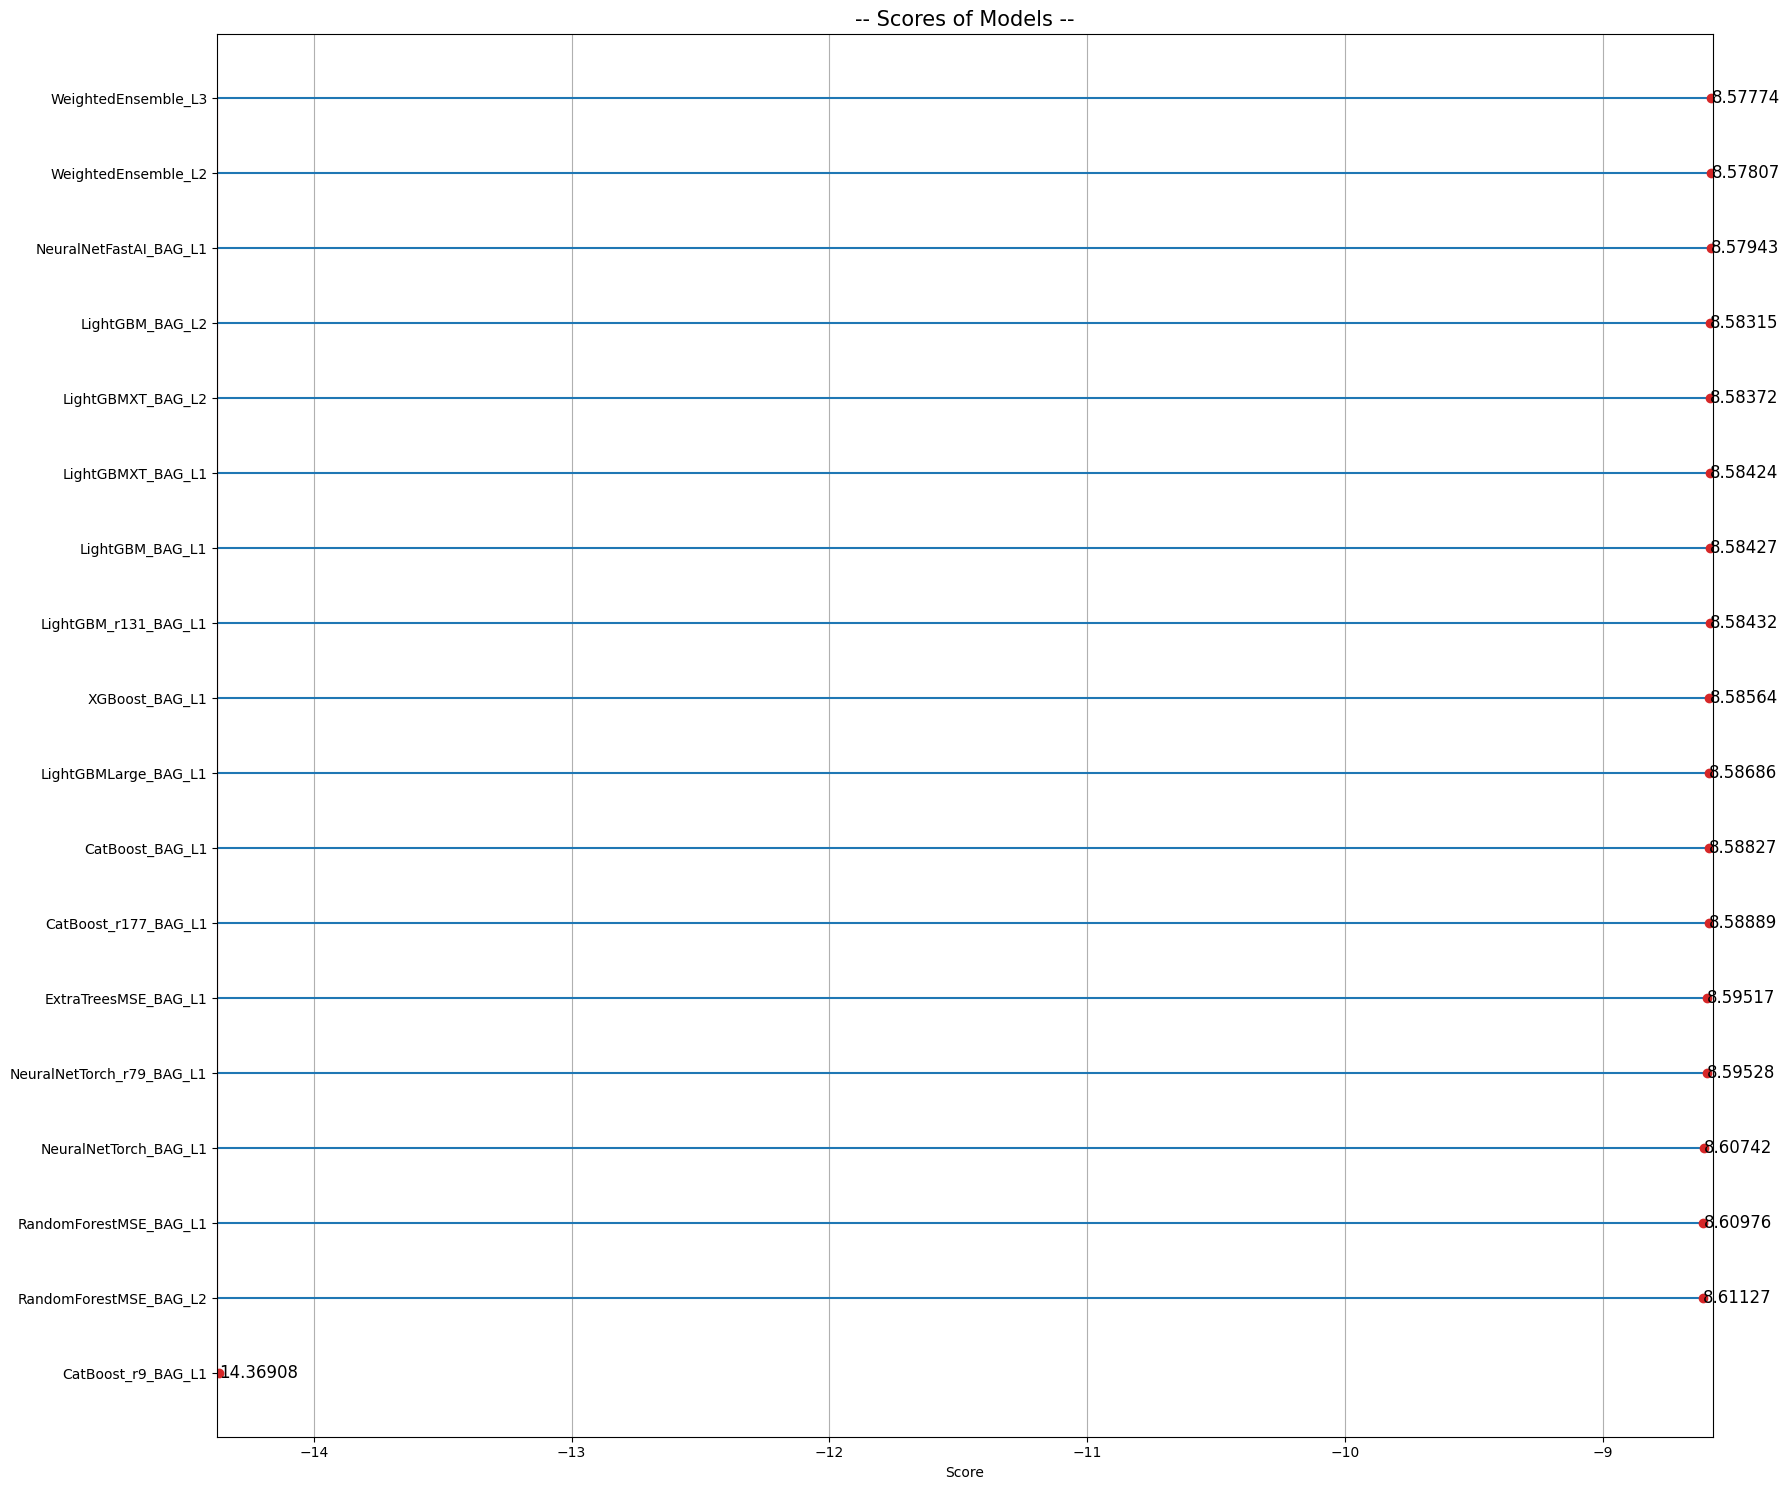

In [17]:
## -- Extract model scores --
result_ = dict(zip(leaderboard['model'], leaderboard['score_val']))
result_df = pd.DataFrame.from_dict(result_, orient='index').sort_values(0)

max_score = result_df.max().item()
min_score = result_df.min().item()

## -- PLOT MODELS & SCORES --
plt.figure(figsize=(18, 15))
plt.stem(
    result_df.index,
    result_df[0],
    orientation = 'horizontal',
    bottom = min_score - 0.0055,
    markerfmt = 'C3o'
)
plt.xlim(min_score - 0.006, max_score + 0.005)
plt.xlabel('Score')
plt.title('-- Scores of Models --', fontsize=15)

for i, value in enumerate(result_df[0]):
    plt.text(value+1e-3, i, f'{abs(value):.5f}', ha='left', va='center', fontdict=dict(size=12))

plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

In [18]:
# predictor.model_names()

In [19]:
# ## -- Permutation Feature Importances --
# feat_imp = predictor.feature_importance(
#                         data = X_test,
#                         # time_limit = 3600,
#                         # model = 'LightGBM_BAG_L1',
#                         # features = None,
#                         # feature_stage = 'transformed',
#                         # subsample_size = 5000,
#                         # num_shuffle_sets = 10,
#                         # include_confidence_band = True,
#                         confidence_level = 0.95,
#                         # silent = False
# ) 

# feat_imp.style.background_gradient(subset=["importance"], cmap="Spectral")

# plt.figure(figsize=(18, 35))
# sns.barplot(data=feat_imp, y=feat_imp.index, x=feat_imp.importance)
# plt.tick_params(axis='y', which='major', labelcolor='r')
# plt.title("Top Features by Permutation")
# plt.tight_layout()
# plt.show()

In [20]:
print(f"""
{'-'*48}
{'█'*5} | - AUTOGLUON NOTEBOOK COMPLETE! - | {'█'*5}
{'-'*48}
""")


------------------------------------------------
█████ | - AUTOGLUON NOTEBOOK COMPLETE! - | █████
------------------------------------------------



In [21]:
## -- OPTIONAL: Clear stored files in memory --
!rm -r {MODELS_PATH}